In [4]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

input_path = "../dataset/quantity_weekly_decor_outlier_fixed.csv"

df = pd.read_csv(input_path)
weeks = df.columns[1:]
dates = pd.date_range(start='2010-12-01', periods=len(weeks), freq='W')
p = 6

def analyze_series_stl(ts, period=6):
    res = {}
    
    ts_diff = ts.diff().dropna()
    adf_diff = adfuller(ts_diff)
    res['ADF_p_value'] = round(adf_diff[1], 4)
    res['Is_Stationarity'] = "Yes" if adf_diff[1] < 0.05 else "No"
    
    stl = STL(ts, period=period, robust=True)
    decomp = stl.fit()
    
    resid = decomp.resid
    trend = decomp.trend
    seasonal = decomp.seasonal
    var_resid = np.var(resid)
    
    var_trend_resid = np.var(trend + resid)
    if var_trend_resid == 0:
        trend_strength = 0
    else:
        trend_strength = max(0, 1 - var_resid / var_trend_resid)
    
    res['Trend_Strength'] = round(trend_strength, 4)
    res['Have_Trend'] = "Yes" if trend_strength > 0.6 else "No"
    
    var_seasonal_resid = np.var(seasonal + resid)
    if var_seasonal_resid == 0:
        seasonal_strength = 0
    else:
        seasonal_strength = max(0, 1 - var_resid / var_seasonal_resid)
        
    res['Seasonal_Strength'] = round(seasonal_strength, 4)
    res['Have_Seasonality'] = "Yes" if seasonal_strength > 0.6 else "No"
    
    return res

final_results = []

for index, row in df.iterrows():
    stock_code = str(row['StockCode'])
    series_data = pd.to_numeric(row[1:], errors='coerce').values.astype(float)
    series_data = np.nan_to_num(series_data, nan=1e-6)
    series_data[series_data <= 0] = 1e-6
    ts = pd.Series(series_data, index=dates)
    
    try:
        stats = analyze_series_stl(ts, period=p)
        stats['StockCode'] = stock_code
        final_results.append(stats)
    except Exception as e:
        print(f"{stock_code}: {e}")

df_results = pd.DataFrame(final_results)
cols = ['StockCode', 'Is_Stationarity', 'ADF_p_value', 'Have_Trend', 'Trend_Strength', 'Have_Seasonality', 'Seasonal_Strength']
df_results = df_results[cols]

print(df_results.to_string(index=False))

StockCode Is_Stationarity  ADF_p_value Have_Trend  Trend_Strength Have_Seasonality  Seasonal_Strength
    22469             Yes       0.0186         No          0.5121               No             0.1086
    22961             Yes       0.0008         No          0.4103               No             0.1059
    21181             Yes       0.0000         No          0.5821               No             0.0000
    21137             Yes       0.0000        Yes          0.8384               No             0.2730
    84978             Yes       0.0004        Yes          0.9407              Yes             0.6526
    21326             Yes       0.0000         No          0.2488               No             0.0000
    22969             Yes       0.0008        Yes          0.6090               No             0.1528
    79321             Yes       0.0002         No          0.5330               No             0.0000
    84945              No       0.0872         No          0.4692               No

In [5]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore")

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

no_trend_stocks = df_results[df_results['Have_Trend'] == 'No']['StockCode'].tolist()

ses_results = []

print(f"Số mã sản phẩm: {len(no_trend_stocks)}/{df.shape[0]}")

for stock in no_trend_stocks:
    series_data = pd.to_numeric(df[df['StockCode'].astype(str) == stock].iloc[0, 1:], errors='coerce').values
    series_data = np.nan_to_num(series_data, nan=1e-6)
    
    test_size = 4
    train_data = series_data[:-test_size]
    test_data = series_data[-test_size:]
    
    try:
        model = SimpleExpSmoothing(train_data, initialization_method="estimated")
        model_fit = model.fit()
        
        forecast = model_fit.forecast(steps=test_size)
        
        mae = mean_absolute_error(test_data, forecast)
        rmse = np.sqrt(mean_squared_error(test_data, forecast))
        mape = mean_absolute_percentage_error(test_data, forecast)
        
        ses_results.append({
            'StockCode': stock,
            'Model': 'ETS(A,N,N)',
            'MAE': round(mae, 4),
            'RMSE': round(rmse, 4),
            'MAPE (%)': round(mape, 2),
            'Forecast': forecast,
            'Actual': test_data,
            'Train_Data': train_data
        })
    except Exception as e:
        print(f"{stock}: {e}")

df_ses_compare = pd.DataFrame(ses_results)
print("\nKết quả")
print(df_ses_compare[['StockCode', 'MAE', 'RMSE', 'MAPE (%)']].head(50))

Số mã sản phẩm: 21/41

Kết quả
   StockCode     MAE    RMSE  MAPE (%)
0      22469  0.4705  0.5115      8.21
1      22961  0.4765  0.5260      8.40
2      21181  1.8762  1.9729     40.25
3      21326  0.7512  0.7776     13.69
4      79321  0.4289  0.4579      8.47
5      84945  0.5965  0.6463     12.06
6      22470  0.6253  0.7445     12.14
7      21166  1.5670  1.6421     30.80
8      22457  0.3115  0.3353      6.07
9      23307  0.4930  0.6881     14.45
10     22791  0.5614  0.5851     13.56
11     82583  0.9415  1.0065     22.45
12    82494L  0.6094  0.7502     16.93
13     82600  0.0984  0.1252      2.17
14     22726  0.4836  0.5391     12.29
15     71477  0.0594  0.0653      0.98
16     22147  1.0915  1.2277     36.30
17     82580  0.0576  0.0808      1.01
18     22294  0.2029  0.2314      5.04
19     22722  0.3762  0.4595      9.91
20     84949  0.0793  0.1099      1.66


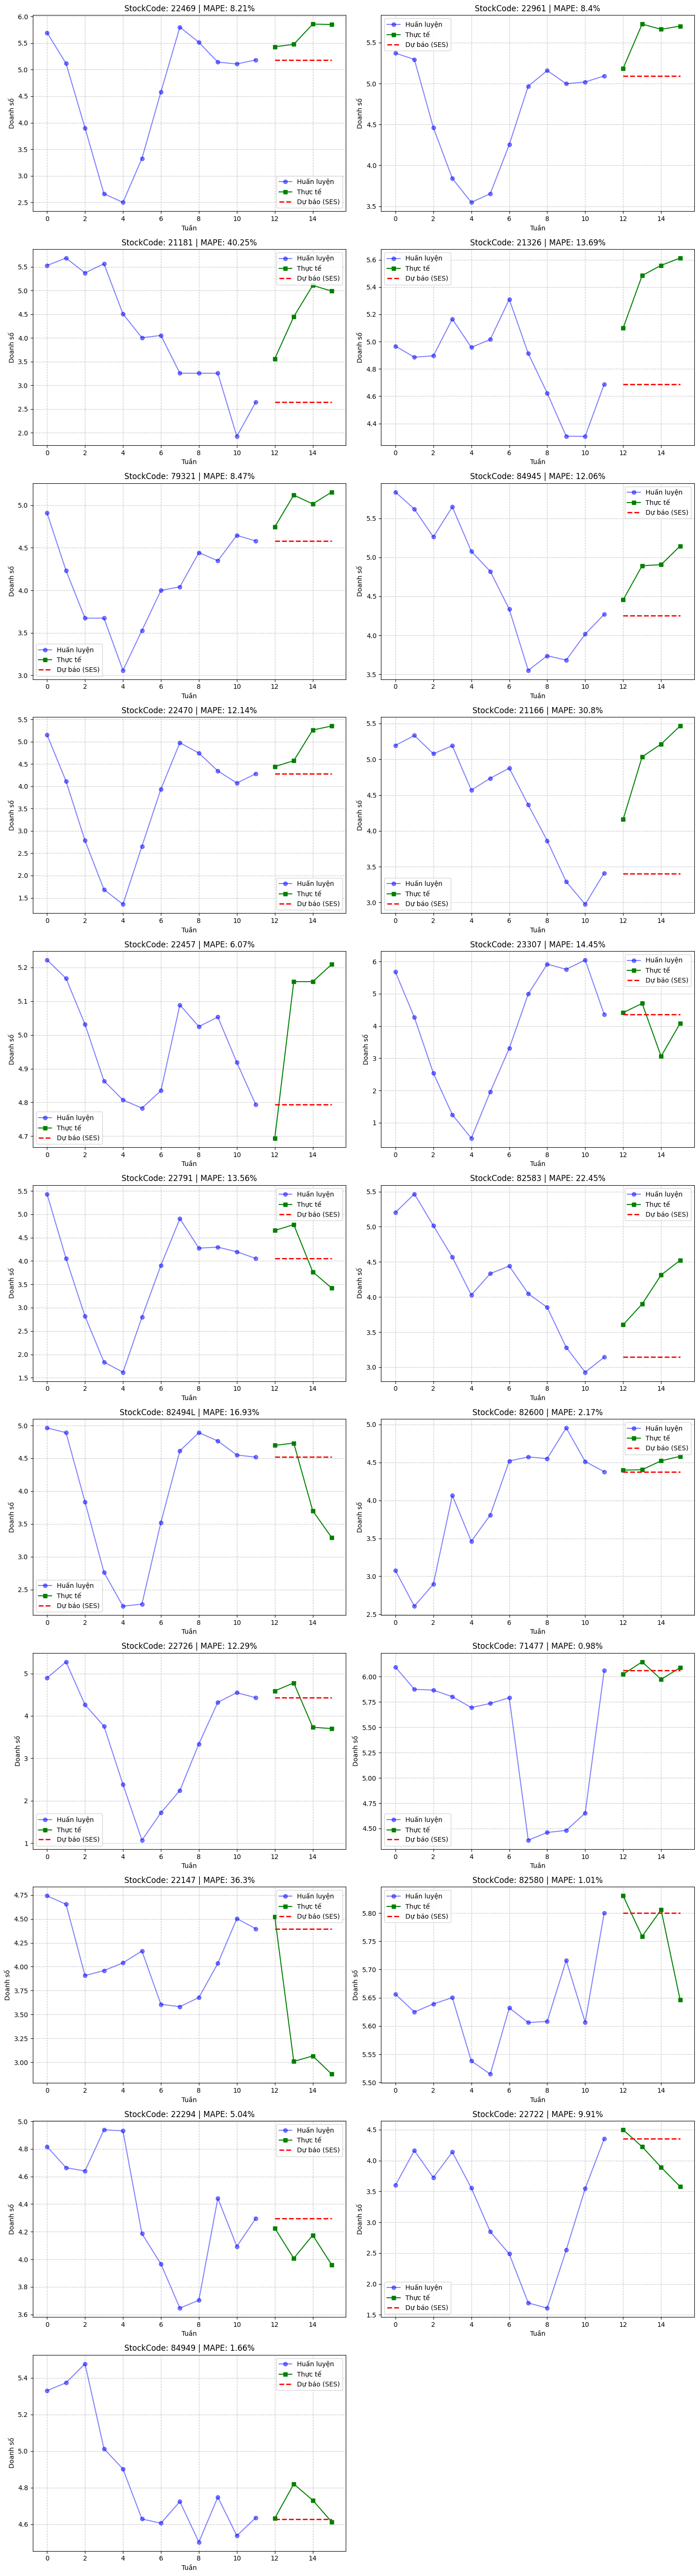

In [9]:
import matplotlib.pyplot as plt

def plot_ses_results(df_results, num_stocks=6):
    num_stocks = min(num_stocks, len(df_results))
    rows = (num_stocks + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(15, 5 * rows))
    axes = axes.flatten()

    for i in range(num_stocks):
        res = df_results.iloc[i]
        train_data = res['Train_Data']
        actual = res['Actual']
        forecast = res['Forecast']
        
        ax = axes[i]
        lookback = 12
        train_idx = np.arange(lookback)
        test_idx = np.arange(lookback, lookback + len(actual))
        
        ax.plot(train_idx, train_data[-lookback:], label='Huấn luyện', color='blue', marker='o', alpha=0.5)
        ax.plot(test_idx, actual, label='Thực tế', color='green', marker='s')
        ax.plot(test_idx, forecast, label='Dự báo (SES)', color='red', linestyle='--', linewidth=2)
        
        ax.set_title(f"StockCode: {res['StockCode']} | MAPE: {res['MAPE (%)']}%")
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xlabel("Tuần")
        ax.set_ylabel("Doanh số")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_ses_results(df_ses_compare, num_stocks=50)